<a href="https://colab.research.google.com/github/gustavo159753/Analise-de-dados/blob/main/topsis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Criando o banco de dados

In [72]:
elementos = ['Palio', 'HB20', 'Corolla']
criterios = ['Consumo (Km/L)', 'Conforto (0 - 10)', 'Preço (R$)', 'Reputação (0-10)']
palio = [15, 6, 25000, 7]
hb20 = [12, 7, 35000, 7]
corolla = [10, 9, 55000, 8]
pesos_criterios = [0.3, 0.05, 0.6, 0.05]

print("Critérios avaliados:", criterios)

Critérios avaliados: ['Consumo (Km/L)', 'Conforto (0 - 10)', 'Preço (R$)', 'Reputação (0-10)']


In [62]:
matriz_d = np.array([palio, hb20, corolla])
matriz_d

array([[   15,     6, 25000,     7],
       [   12,     7, 35000,     7],
       [   10,     9, 55000,     8]])

In [63]:
import numpy as np
# normalizar: Valores do vetor vn / módulo da somatória dos vetores elevado ao quadrado. Ex: sqrt(12**2 + 15**2 + 18**2)

matriz_normalizada = np.zeros_like(matriz_d, dtype=float)

for j in range(matriz_d.shape[1]): # Iterar sobre as colunas
    coluna = matriz_d[:, j]
    norma = np.linalg.norm(coluna) # Calcular a norma L2 da coluna
    if norma != 0:
        matriz_normalizada[:, j] = coluna / norma
    else:
        matriz_normalizada[:, j] = 0 # Lidar com o caso em que a norma é zero para evitar divisão por zero

print("Matriz Normalizada:")
print(matriz_normalizada)

Matriz Normalizada:
[[0.69263564 0.46569032 0.35805744 0.54997194]
 [0.55410852 0.54330537 0.50128041 0.54997194]
 [0.4617571  0.69853547 0.78772636 0.62853936]]


In [64]:
# MULTIPLICANDO CADA COLUNA PELO PESO DO CRITÉRIO
matrizR = matriz_normalizada * pesos_criterios

print("Matriz Ponderada (matrizR):")
print(matrizR)

Matriz Ponderada (matrizR):
[[0.20779069 0.02328452 0.21483446 0.0274986 ]
 [0.16623255 0.02716527 0.30076825 0.0274986 ]
 [0.13852713 0.03492677 0.47263582 0.03142697]]


In [65]:
tipos_criterios = ['custo', 'beneficio', 'custo', 'beneficio']
print("Classificação dos critérios:", tipos_criterios)

Classificação dos critérios: ['custo', 'beneficio', 'custo', 'beneficio']


In [66]:
a_plus = []

for j in range(matrizR.shape[1]): # Iterate over columns
    column = matrizR[:, j]
    criterion_type = tipos_criterios[j]

    if criterion_type == 'beneficio':
        a_plus.append(np.max(column))
    elif criterion_type == 'custo':
        a_plus.append(np.min(column))

a_plus = np.array(a_plus)

print("Ideal Positive Solution (A+):")
print(a_plus)

Ideal Positive Solution (A+):
[0.13852713 0.03492677 0.21483446 0.03142697]


In [67]:
a_minus = []

for j in range(matrizR.shape[1]): # Iterate over columns
    column = matrizR[:, j]
    criterion_type = tipos_criterios[j]

    if criterion_type == 'beneficio':
        a_minus.append(np.min(column))
    elif criterion_type == 'custo':
        a_minus.append(np.max(column))

a_minus = np.array(a_minus)

print("Ideal Negative Solution (A-):")
print(a_minus)

Ideal Negative Solution (A-):
[0.20779069 0.02328452 0.47263582 0.0274986 ]


In [68]:
dist_a_plus = []

for i in range(matrizR.shape[0]): # Iterate over rows
    distance = np.linalg.norm(matrizR[i, :] - a_plus)
    dist_a_plus.append(distance)

dist_a_plus = np.array(dist_a_plus)

print("Euclidean Distances to Ideal Positive Solution (A+):")
print(dist_a_plus)

Euclidean Distances to Ideal Positive Solution (A+):
[0.07034498 0.09070766 0.25780135]


In [69]:
dist_a_minus = []

for i in range(matrizR.shape[0]): # Iterate over rows
    distance = np.linalg.norm(matrizR[i, :] - a_minus)
    dist_a_minus.append(distance)

dist_a_minus = np.array(dist_a_minus)

print("Euclidean Distances to Ideal Negative Solution (A-):")
print(dist_a_minus)

Euclidean Distances to Ideal Negative Solution (A-):
[0.25780135 0.17686323 0.07034498]


In [70]:
# Cálculo das Distâncias Euclidianas
dist_a_plus = []
dist_a_minus = []

for i in range(matrizR.shape[0]):
    # Distância para a solução ideal positiva (di+)
    d_plus = np.sqrt(np.sum((a_plus - matrizR[i, :])**2))
    dist_a_plus.append(d_plus)

    # Distância para a solução ideal negativa (di-)
    d_minus = np.sqrt(np.sum((a_minus - matrizR[i, :])**2))
    dist_a_minus.append(d_minus)

dist_a_plus = np.array(dist_a_plus)
dist_a_minus = np.array(dist_a_minus)

print("Distâncias para a Solução Ideal Positiva (di+):")
for i, d in enumerate(dist_a_plus):
    print(f"{elementos[i]}: {d:.4f}")

print("\nDistâncias para a Solução Ideal Negativa (di-):")
for i, d in enumerate(dist_a_minus):
    print(f"{elementos[i]}: {d:.4f}")

Distâncias para a Solução Ideal Positiva (di+):
Palio: 0.0703
HB20: 0.0907
Corolla: 0.2578

Distâncias para a Solução Ideal Negativa (di-):
Palio: 0.2578
HB20: 0.1769
Corolla: 0.0703


In [71]:
# Cálculo da Proximidade Relativa (C_i / Ksi)
closeness = []

for i in range(len(dist_a_plus)):
    # Nota: A fórmula padrão do TOPSIS é di- / (di+ + di-)
    valor_ksi = dist_a_minus[i] / (dist_a_plus[i] + dist_a_minus[i])
    closeness.append(valor_ksi)

closeness = np.array(closeness)

# Criando o DataFrame para o Ranking
ranking_df = pd.DataFrame({
    'Alternativa': elementos,
    'di+': dist_a_plus,
    'di-': dist_a_minus,
    'Ksi (C_i)': closeness
})

# Ordenando do melhor para o pior (maior Ksi é melhor)
ranking_df = ranking_df.sort_values(by='Ksi (C_i)', ascending=False)

print("Ranking Final das Alternativas:")
display(ranking_df)

Ranking Final das Alternativas:


,Alternativa,di+,di-,Ksi (C_i)
0,Palio,0.070345,0.257801,0.785629
1,HB20,0.090708,0.176863,0.660996
2,Corolla,0.257801,0.070345,0.214371


# Task
Perform a comprehensive sensitivity and robustness analysis on the car ranking (Palio, HB20, Corolla) by simulating variations in weight criteria (e.g., increasing 'Conforto' and decreasing 'Preço'), comparing Euclidean (L2) vs. Manhattan (L1) distance metrics, and applying small perturbations to the decision matrix. Generate correlation plots and heatmaps to visualize the impact of each criterion on the final score (Ksi), and provide a technical summary identifying scenarios where the Palio is no longer the top choice.

## Análise de Sensibilidade

### Subtask:
Simular variações nos pesos dos critérios para observar como o ranking das alternativas se comporta.


**Reasoning**:
I will create a function to encapsulate the TOPSIS logic and then define multiple weight scenarios to simulate sensitivity analysis, storing the results in a DataFrame for comparison.



In [73]:
def run_topsis(weights):
    # 1. Weighted Normalized Decision Matrix
    matrix_r = matriz_normalizada * weights

    # 2. Determine Ideal Positive (A+) and Negative (A-) Solutions
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        column = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(column))
            a_minus.append(np.min(column))
        else:
            a_plus.append(np.min(column))
            a_minus.append(np.max(column))

    a_plus = np.array(a_plus)
    a_minus = np.array(a_minus)

    # 3. Calculate Euclidean Distances
    dist_p = np.sqrt(np.sum((matrix_r - a_plus)**2, axis=1))
    dist_m = np.sqrt(np.sum((matrix_r - a_minus)**2, axis=1))

    # 4. Calculate Relative Closeness (Ksi)
    ksi = dist_m / (dist_p + dist_m)
    return ksi

# Define Scenarios
scenarios = {
    'Base': [0.3, 0.05, 0.6, 0.05], # Original
    'Foco Conforto': [0.1, 0.7, 0.1, 0.1],
    'Preço Reduzido': [0.4, 0.1, 0.1, 0.4],
    'Equilibrado': [0.25, 0.25, 0.25, 0.25]
}

results = {}
for name, w in scenarios.items():
    results[name] = run_topsis(w)

# Create DataFrame
sensitivity_df = pd.DataFrame(results, index=elementos)
print('Resultados da Análise de Sensibilidade (Score Ksi):')
print(sensitivity_df)

Resultados da Análise de Sensibilidade (Score Ksi):
             Base  Foco Conforto  Preço Reduzido  Equilibrado
Palio    0.785629       0.206797        0.299924     0.560300
HB20     0.660996       0.363456        0.543014     0.573527
Corolla  0.214371       0.793203        0.700076     0.439700


**Reasoning**:
With the sensitivity analysis results stored in the `sensitivity_df` DataFrame, I will now create a bar chart to visualize how the relative closeness (Ksi) of each car changes across the different weight scenarios, fulfilling the final part of the instructions.



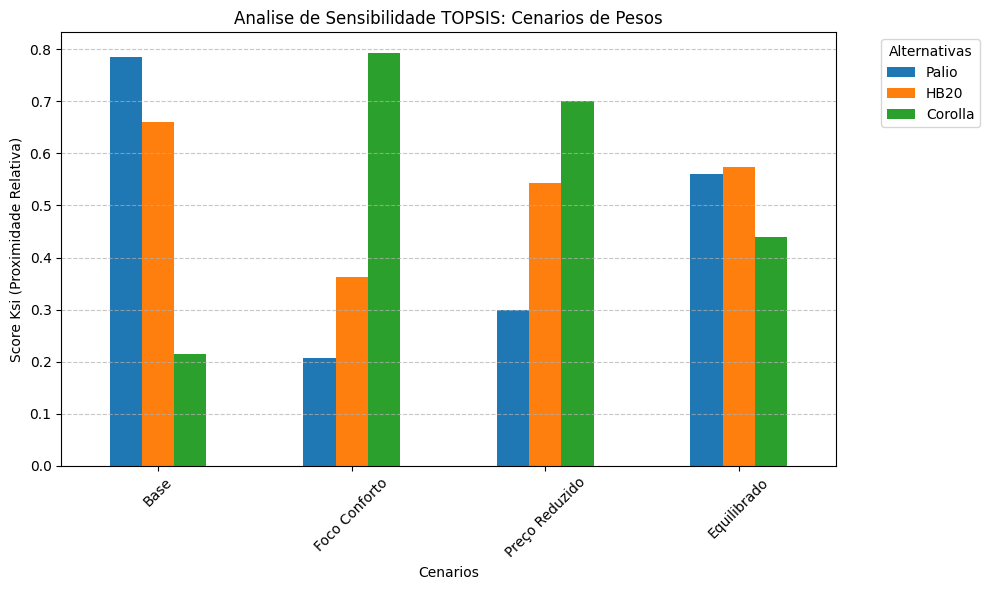

In [75]:
import matplotlib.pyplot as plt

sensitivity_df.T.plot(kind="bar", figsize=(10, 6))
plt.title("Analise de Sensibilidade TOPSIS: Cenarios de Pesos")
plt.xlabel("Cenarios")
plt.ylabel("Score Ksi (Proximidade Relativa)")
plt.legend(title="Alternativas", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

# Task
# Plan:
* **Análise Comparativa de Métricas (L1 vs L2)**: Implementar uma variação do TOPSIS utilizando a Distância de Manhattan (L1) e comparar com os resultados da Euclidiana (L2) para verificar a estabilidade do ranking.
* **Análise de Robustez com Perturbações**: Aplicar pequenas variações aleatórias (ruído) na matriz de decisão original e executar o TOPSIS múltiplas vezes para calcular a frequência com que cada carro termina em primeiro lugar.
* **Correlações e Heatmap**: Gerar um heatmap de correlação para identificar como cada critério (Consumo, Preço, etc.) impacta estatisticamente o score final de proximidade (Ksi).
* **Final Task**: Apresentar o resumo técnico final com as visualizações consolidadas, respondendo se o Palio é de fato a escolha mais robusta.

# Task:
Execute an advanced robustness analysis of the car ranking by comparing Euclidean (L2) and Manhattan (L1) distances, performing a Monte Carlo simulation with random perturbations to the decision matrix to calculate winning frequencies, and generating a correlation heatmap to quantify the impact of criteria like 'Consumo' and 'Preço' on the final Ksi score, concluding with a technical assessment of the Palio's dominance.

## Análise Comparativa de Métricas (L1 vs L2)

### Subtask:
Implementar uma variação do TOPSIS utilizando a Distância de Manhattan (L1) e comparar com os resultados da Euclidiana (L2) para verificar a estabilidade do ranking.


**Reasoning**:
I will update the TOPSIS function to support both Euclidean (L2) and Manhattan (L1) distance metrics, then calculate the results for the base scenario using both metrics to compare the final rankings.



Comparativo de Multiplas Metricas de Distancia:


,Euclidiana (L2),Manhattan (L1),Minkowski (p=3),Chebyshev (L-inf)
Palio,0.785629,0.752407,0.787953,0.788227
HB20,0.660996,0.634220,0.665205,0.666667
Corolla,0.214371,0.247593,0.212047,0.211773


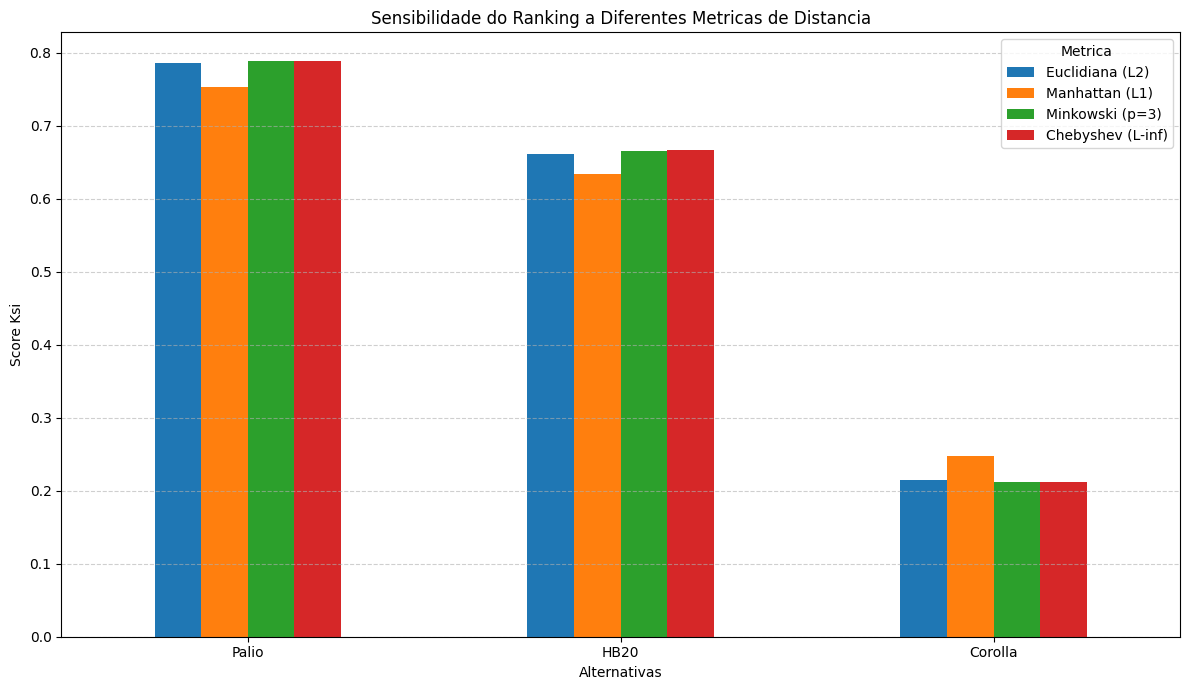

In [79]:
def run_topsis_metrics(weights, metric='L2', p_val=3):
    # 1. Weighted Normalized Decision Matrix
    matrix_r = matriz_normalizada * weights

    # 2. Determine Ideal Positive (A+) and Negative (A-) Solutions
    a_plus = []
    a_minus = []
    for j in range(matrix_r.shape[1]):
        column = matrix_r[:, j]
        if tipos_criterios[j] == 'beneficio':
            a_plus.append(np.max(column))
            a_minus.append(np.min(column))
        else:
            a_plus.append(np.min(column))
            a_minus.append(np.max(column))

    a_plus = np.array(a_plus)
    a_minus = np.array(a_minus)

    # 3. Calculate Distances based on selected metric
    if metric == 'L2':
        dist_p = np.sqrt(np.sum((matrix_r - a_plus)**2, axis=1))
        dist_m = np.sqrt(np.sum((matrix_r - a_minus)**2, axis=1))
    elif metric == 'L1':
        dist_p = np.sum(np.abs(matrix_r - a_plus), axis=1)
        dist_m = np.sum(np.abs(matrix_r - a_minus), axis=1)
    elif metric == 'Minkowski':
        dist_p = np.sum(np.abs(matrix_r - a_plus)**p_val, axis=1)**(1/p_val)
        dist_m = np.sum(np.abs(matrix_r - a_minus)**p_val, axis=1)**(1/p_val)
    elif metric == 'Chebyshev':
        dist_p = np.max(np.abs(matrix_r - a_plus), axis=1)
        dist_m = np.max(np.abs(matrix_r - a_minus), axis=1)

    # 4. Calculate Relative Closeness (Ksi)
    ksi = dist_m / (dist_p + dist_m)
    return ksi

# Base weights
base_weights = [0.3, 0.05, 0.6, 0.05]

# Run TOPSIS with multiple metrics
metrics_results = {
    'Euclidiana (L2)': run_topsis_metrics(base_weights, metric='L2'),
    'Manhattan (L1)': run_topsis_metrics(base_weights, metric='L1'),
    'Minkowski (p=3)': run_topsis_metrics(base_weights, metric='Minkowski'),
    'Chebyshev (L-inf)': run_topsis_metrics(base_weights, metric='Chebyshev')
}

comparison_metrics_df = pd.DataFrame(metrics_results, index=elementos)

print('Comparativo de Multiplas Metricas de Distancia:')
display(comparison_metrics_df)

# Visualization
comparison_metrics_df.plot(kind='bar', figsize=(12, 7))
plt.title('Sensibilidade do Ranking a Diferentes Metricas de Distancia')
plt.xlabel('Alternativas')
plt.ylabel('Score Ksi')
plt.xticks(rotation=0)
plt.legend(title='Metrica', bbox_to_anchor=(1, 1))
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Análise de Robustez com Perturbações

### Subtask:
Aplicar pequenas variações aleatórias na matriz de decisão original e executar o TOPSIS múltiplas vezes para calcular a frequência com que cada carro termina em primeiro lugar.


**Reasoning**:
I will perform a Monte Carlo simulation by adding small random Gaussian noise to the normalized decision matrix, running the TOPSIS logic multiple times to calculate how frequently each car wins, and then visualize the win percentages to assess ranking robustness.



Frequência de Vitórias (%):
Palio      80.3
HB20       19.7
Corolla     0.0
Name: proportion, dtype: float64


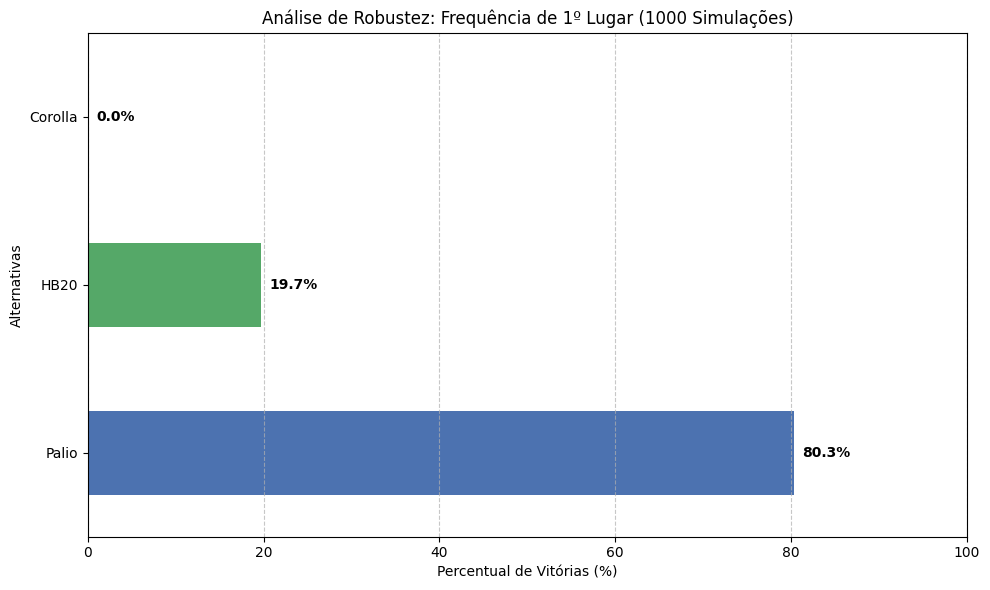

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Set seed for reproducibility
np.random.seed(42)

# 2. Simulation parameters
n_simulations = 1000
noise_std = 0.05
base_weights = [0.3, 0.05, 0.6, 0.05]
winners = []

# 3. Simulation Loop
for _ in range(n_simulations):
    # Add small Gaussian noise to the normalized matrix
    noise = np.random.normal(0, noise_std, matriz_normalizada.shape)
    perturbed_matrix = np.clip(matriz_normalizada + noise, 0, 1) # Keep values within valid bounds

    # Temporarily override the global matrix used by the function logic if necessary,
    # or pass it explicitly. Since run_topsis_metrics uses 'matriz_normalizada' from global scope,
    # we adjust the logic slightly to be clean.

    def run_topsis_internal(matrix, weights):
        matrix_r = matrix * weights
        a_plus = []
        a_minus = []
        for j in range(matrix_r.shape[1]):
            col = matrix_r[:, j]
            if tipos_criterios[j] == 'beneficio':
                a_plus.append(np.max(col))
                a_minus.append(np.min(col))
            else:
                a_plus.append(np.min(col))
                a_minus.append(np.max(col))
        a_p, a_m = np.array(a_plus), np.array(a_minus)
        dist_p = np.sqrt(np.sum((matrix_r - a_p)**2, axis=1))
        dist_m = np.sqrt(np.sum((matrix_r - a_m)**2, axis=1))
        return dist_m / (dist_p + dist_m)

    # Calculate scores for this iteration
    scores = run_topsis_internal(perturbed_matrix, base_weights)
    winners.append(elementos[np.argmax(scores)])

# 4. Calculate frequencies
win_counts = pd.Series(winners).value_counts(normalize=True) * 100
for car in elementos:
    if car not in win_counts: win_counts[car] = 0.0
win_counts = win_counts.reindex(elementos)

print("Frequência de Vitórias (%):")
print(win_counts)

# 5. Visualization
plt.figure(figsize=(10, 6))
win_counts.plot(kind='barh', color=['#4C72B0', '#55A868', '#C44E52'])
plt.title('Análise de Robustez: Frequência de 1º Lugar (1000 Simulações)')
plt.xlabel('Percentual de Vitórias (%)')
plt.ylabel('Alternativas')
plt.xlim(0, 100)
for i, v in enumerate(win_counts):
    plt.text(v + 1, i, f"{v:.1f}%", va='center', fontweight='bold')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

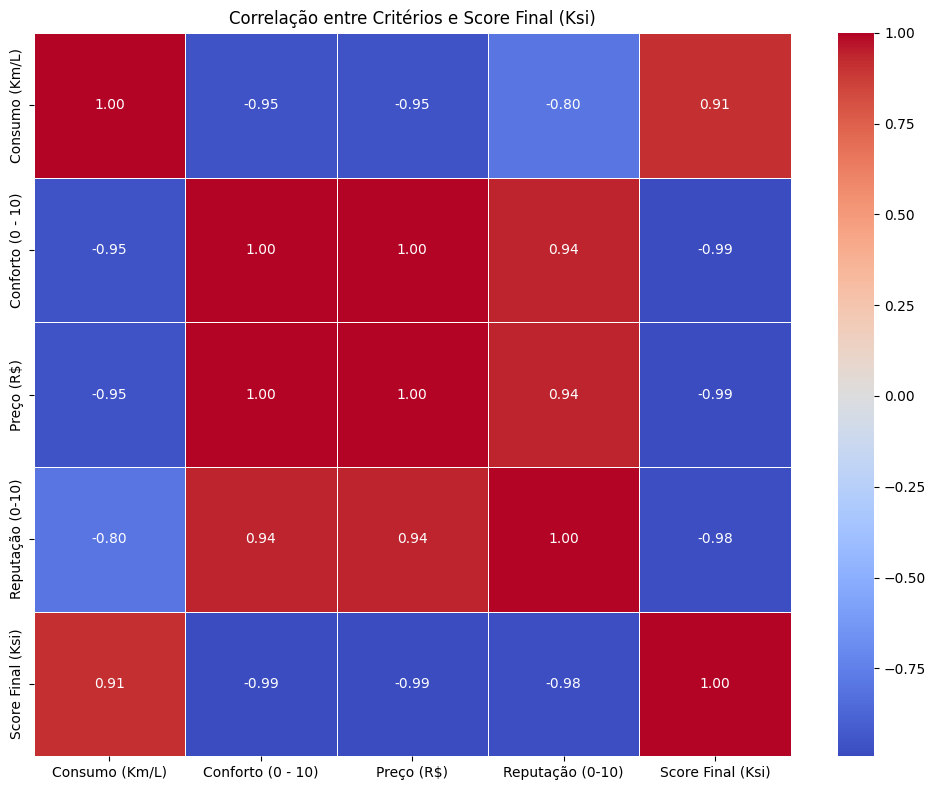

In [81]:
import seaborn as sns

# 1. Create a DataFrame combining criteria and the final score (Ksi)
# Using matrizR (Weighted Normalized Matrix) and closeness (Base scenario Ksi)
corr_data = pd.DataFrame(matrizR, columns=criterios)
corr_data['Score Final (Ksi)'] = closeness

# 2. Calculate Pearson correlation matrix
corr_matrix = corr_data.corr()

# 3. Generate the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlação entre Critérios e Score Final (Ksi)')
plt.tight_layout()
plt.show()